# Análisis de Componentes Principales — Dataset de Fórmula 1

**Análisis Multivariado y Descubrimiento de Patrones**  
Licenciatura en Ciencia de Datos

---

**Unidad de análisis:** cada observación es una *combinación driver–temporada* (ej: Hamilton 2019, Verstappen 2023).  
**Período:** temporadas 2004–2024 (el dato de velocidad en vuelta rápida está disponible desde 2004).  
**Variables para PCA:** 7 variables numéricas que resumen el desempeño de cada piloto en cada temporada.

## 1. Importación de librerías

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')

DATA_PATH = '../../data/raw/'

## 2. Carga y preprocesamiento de datos

### 2.1 Lectura de archivos

In [46]:
races        = pd.read_csv(DATA_PATH + 'races.csv')
results      = pd.read_csv(DATA_PATH + 'results.csv')
drivers      = pd.read_csv(DATA_PATH + 'drivers.csv')
constructors = pd.read_csv(DATA_PATH + 'constructors.csv')
status       = pd.read_csv(DATA_PATH + 'status.csv')

print(f"Carreras totales en el dataset: {len(races)} ({races['year'].min()}–{races['year'].max()})")
print(f"Resultados totales:             {len(results):,}")
print(f"Pilotos únicos:                 {results['driverId'].nunique()}")

Carreras totales en el dataset: 1125 (1950–2024)
Resultados totales:             26,759
Pilotos únicos:                 861


### 2.2 Filtro desde el año 2000 y unión de tablas

In [47]:
# Filtrar carreras desde 2004 (año desde el que está disponible fastestLapSpeed)
races_mod = races[races['year'] >= 2004][['raceId', 'year', 'name']].copy()

# Unir resultados con carreras
df = results.merge(races_mod, on='raceId')

# Agregar nombre y nacionalidad del piloto
drivers['driver_name'] = drivers['forename'] + ' ' + drivers['surname']
df = df.merge(drivers[['driverId', 'driver_name', 'nationality']], on='driverId')

# Agregar nombre de la escudería
df = df.merge(
    constructors[['constructorId', 'name']].rename(columns={'name': 'constructor'}),
    on='constructorId'
)

print(f"Resultados desde 2004: {len(df):,} filas")
print(f"Temporadas: {df['year'].min()}–{df['year'].max()}")
df.head(3)

Resultados desde 2004: 8,650 filas
Temporadas: 2004–2024


,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,...,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId,year,name,driver_name,nationality,constructor
0,1,18,1,1,22,1,1,1,1,10.0,...,39,2,1:27.452,218.300,1,2008,Australian Grand Prix,Lewis Hamilton,British,McLaren
1,2,18,2,2,3,5,2,2,2,8.0,...,41,3,1:27.739,217.586,1,2008,Australian Grand Prix,Nick Heidfeld,German,BMW Sauber
2,3,18,3,3,7,7,3,3,3,6.0,...,41,5,1:28.090,216.719,1,2008,Australian Grand Prix,Nico Rosberg,German,Williams


### 2.3 Limpieza y variables derivadas por carrera

In [48]:
# Convertir columnas que tienen '\N' (NULL en Ergast) a numérico
df['position']        = pd.to_numeric(df['position'].replace('\\N', np.nan), errors='coerce')
df['fastestLapSpeed'] = pd.to_numeric(df['fastestLapSpeed'].replace('\\N', np.nan), errors='coerce')
df['grid']            = pd.to_numeric(df['grid'], errors='coerce')

# grid == 0 significa largada desde el pitlane → se trata como dato faltante
df.loc[df['grid'] == 0, 'grid'] = np.nan

# Indicadores binarios por carrera
df['is_dnf']    = df['position'].isna().astype(int)           # no clasificado / retirado
df['is_win']    = (df['position'] == 1).astype(int)           # victoria
df['is_podium'] = (df['position'] <= 3).fillna(0).astype(int) # top-3

# Velocidad relativa en vuelta rápida: z-score dentro de cada carrera.
# Permite comparar entre circuitos y eras distintas.
df['rel_speed'] = df.groupby('raceId')['fastestLapSpeed'].transform(
    lambda x: (x - x.mean()) / x.std(ddof=0)
)

print("Variables derivadas creadas: is_dnf, is_win, is_podium, rel_speed")
df[['driver_name', 'year', 'grid', 'position', 'points',
    'is_dnf', 'is_win', 'is_podium', 'rel_speed']].head(5)

Variables derivadas creadas: is_dnf, is_win, is_podium, rel_speed


,driver_name,year,grid,position,points,is_dnf,is_win,is_podium,rel_speed
0,Lewis Hamilton,2008,1.0,1.0,10.0,0,1,1,1.282837
1,Nick Heidfeld,2008,5.0,2.0,8.0,0,0,1,1.053469
2,Nico Rosberg,2008,7.0,3.0,6.0,0,0,1,0.774952
3,Fernando Alonso,2008,11.0,4.0,5.0,0,0,0,0.371792
4,Heikki Kovalainen,2008,3.0,5.0,4.0,0,0,0,1.310143


### 2.4 Agregación a nivel driver–temporada

In [49]:
# Escudería principal por driver-temporada (la que más carreras corrió)
main_constructor = (
    df.groupby(['year', 'driverId', 'constructor'])
    .size().reset_index(name='n')
    .sort_values('n', ascending=False)
    .drop_duplicates(['year', 'driverId'])
    [['year', 'driverId', 'constructor']]
)

# Agregación de variables numéricas
driver_season = (
    df.groupby(['year', 'driverId', 'driver_name', 'nationality'])
    .agg(
        n_races         = ('raceId',        'count'),
        avg_grid        = ('grid',          'mean'),
        avg_pos_order   = ('positionOrder', 'mean'),
        points_per_race = ('points',        'mean'),
        win_rate        = ('is_win',        'mean'),
        podium_rate     = ('is_podium',     'mean'),
        dnf_rate        = ('is_dnf',        'mean'),
        avg_rel_speed   = ('rel_speed',     'mean'),  # promedio de z-scores disponibles
    )
    .reset_index()
)

driver_season = driver_season.merge(main_constructor, on=['year', 'driverId'])

# Filtrar temporadas con al menos 5 carreras (evitar apariciones esporádicas)
driver_season = driver_season[driver_season['n_races'] >= 5].copy()

# Era según reglamento técnico
def asignar_era(year):
    if year <= 2009:   return 'V10/V8 (2004-09)'
    elif year <= 2013: return 'V8 (2010-13)'
    elif year <= 2021: return 'Híbrido (2014-21)'
    else:              return 'Nuevos reglamentos (2022+)'

driver_season['era'] = driver_season['year'].apply(asignar_era)

print(f"Dataset driver-temporada: {driver_season.shape}")
print(f"Período cubierto: {driver_season['year'].min()}–{driver_season['year'].max()}")
driver_season.head()

Dataset driver-temporada: (464, 14)
Período cubierto: 2004–2024


,year,driverId,driver_name,nationality,n_races,avg_grid,avg_pos_order,points_per_race,win_rate,podium_rate,dnf_rate,avg_rel_speed,constructor,era
0,2004,2,Nick Heidfeld,German,18,16.000000,14.000000,0.166667,0.000000,0.000000,0.388889,-0.703931,Jordan,V10/V8 (2004-09)
1,2004,4,Fernando Alonso,Spanish,18,7.555556,7.388889,3.277778,0.000000,0.222222,0.277778,0.692150,Renault,V10/V8 (2004-09)
2,2004,8,Kimi Räikkönen,Finnish,18,8.222222,11.000000,2.500000,0.055556,0.222222,0.444444,0.393008,McLaren,V10/V8 (2004-09)
4,2004,11,Takuma Sato,Japanese,18,8.222222,10.055556,1.888889,0.000000,0.055556,0.277778,0.411961,BAR,V10/V8 (2004-09)
5,2004,13,Felipe Massa,Brazilian,18,13.388889,10.666667,0.666667,0.000000,0.000000,0.222222,-0.050215,Sauber,V10/V8 (2004-09)


## 3. Análisis Exploratorio

### 3.1 Estadísticas descriptivas

In [50]:
NUMERIC_VARS = ['avg_grid', 'avg_pos_order', 'points_per_race',
                'win_rate', 'podium_rate', 'dnf_rate', 'avg_rel_speed']

VAR_LABELS = {
    'avg_grid':         'Posición de salida\n(promedio)',
    'avg_pos_order':    'Posición de llegada\n(promedio)',
    'points_per_race':  'Puntos por carrera',
    'win_rate':         'Tasa de victorias',
    'podium_rate':      'Tasa de podios',
    'dnf_rate':         'Tasa de abandono',
    'avg_rel_speed':    'Velocidad relativa\n(z-score promedio)',
}

LABELS_SHORT = {
    'avg_grid':         'Grid prom.',
    'avg_pos_order':    'Pos. llegada prom.',
    'points_per_race':  'Puntos/carrera',
    'win_rate':         'Tasa victorias',
    'podium_rate':      'Tasa podios',
    'dnf_rate':         'Tasa abandono',
    'avg_rel_speed':    'Vel. relativa',
}

ERA_COLORS = {
    'V10/V8 (2004-09)':           '#2196F3',
    'V8 (2010-13)':               '#4CAF50',
    'Híbrido (2014-21)':          '#FF9800',
    'Nuevos reglamentos (2022+)': '#9C27B0',
}
ERA_ORDER = list(ERA_COLORS.keys())

driver_season[NUMERIC_VARS].describe().round(3)

,avg_grid,avg_pos_order,points_per_race,win_rate,podium_rate,dnf_rate,avg_rel_speed
count,464.000,464.000,464.000,464.000,464.000,464.000,464.000
mean,11.226,11.247,3.817,0.045,0.137,0.191,-0.037
std,5.035,4.165,4.909,0.121,0.228,0.129,0.715
min,1.263,1.273,0.000,0.000,0.000,0.000,-2.228
25%,7.392,8.233,0.310,0.000,0.000,0.095,-0.437
50%,11.174,11.737,1.763,0.000,0.000,0.167,0.000
75%,14.739,14.206,5.403,0.000,0.167,0.273,0.453
max,23.300,20.950,24.091,0.864,0.955,0.700,1.461


### 3.2 Análisis univariado — distribuciones

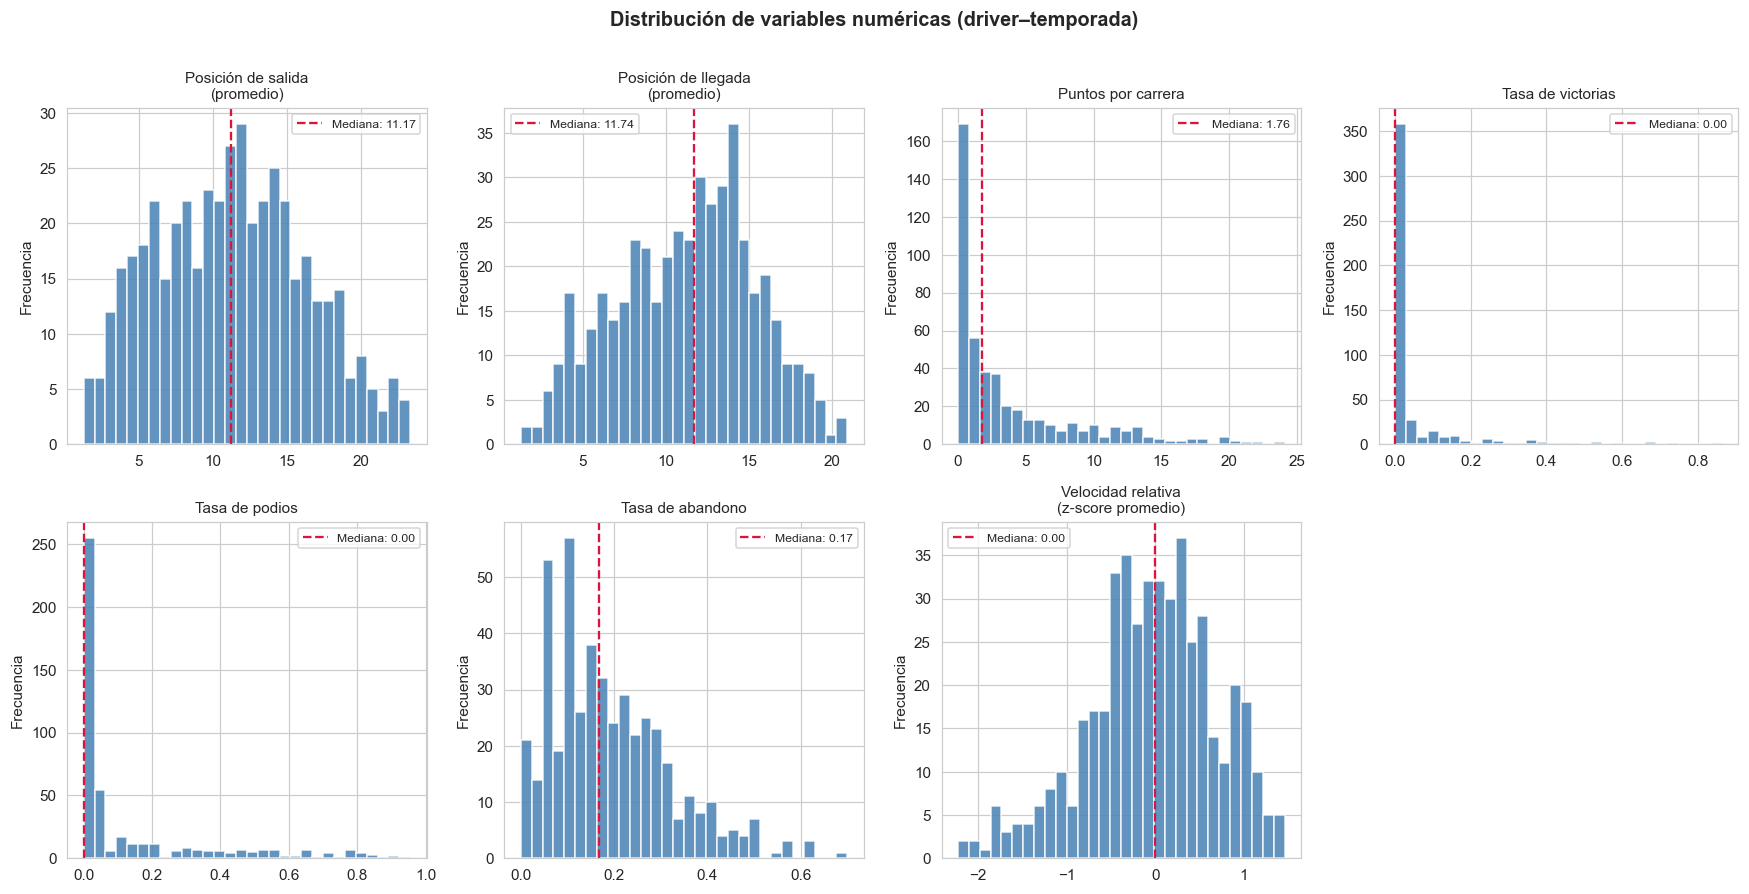

In [51]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

for i, var in enumerate(NUMERIC_VARS):
    data = driver_season[var].dropna()
    axes[i].hist(data, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].axvline(data.median(), color='crimson', linestyle='--',
                    linewidth=1.5, label=f'Mediana: {data.median():.2f}')
    axes[i].set_title(VAR_LABELS[var], fontsize=10)
    axes[i].legend(fontsize=8)
    axes[i].set_ylabel('Frecuencia')

axes[-1].set_visible(False)
fig.suptitle('Distribución de variables numéricas (driver–temporada)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../../reports/figures/univariado_histogramas.png', bbox_inches='tight', dpi=150)
plt.show()

### 3.3 Análisis univariado — variables categóricas

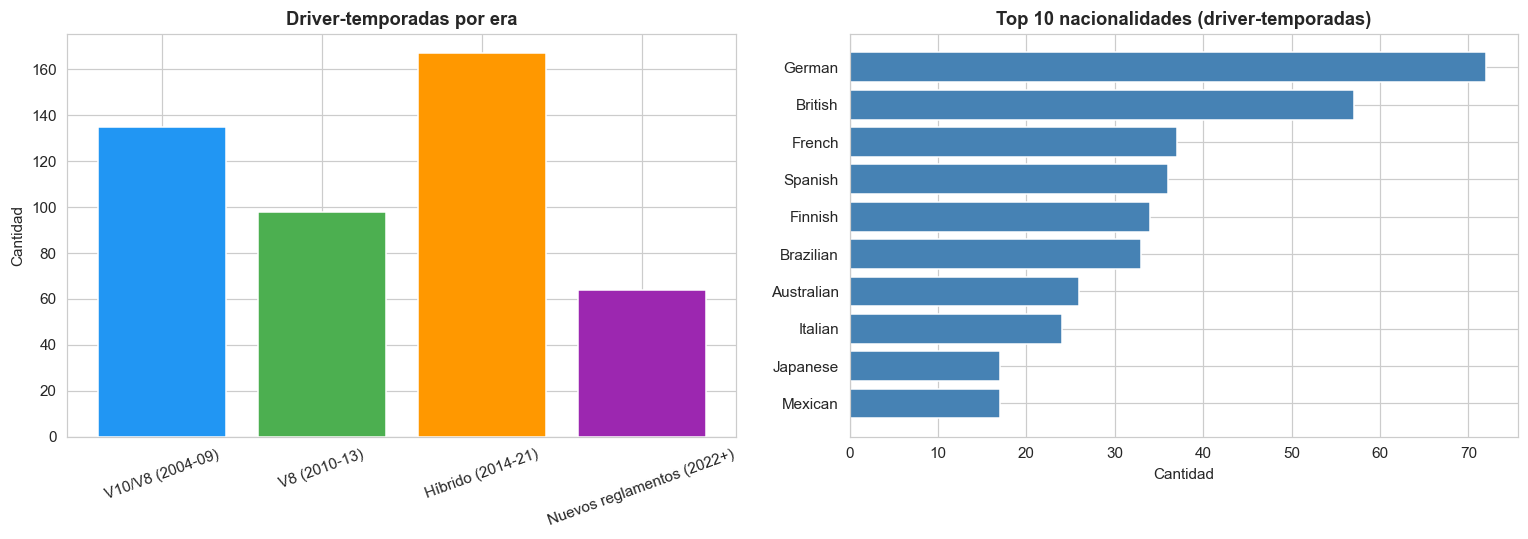

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución por era
era_counts = driver_season['era'].value_counts().reindex(ERA_ORDER)
axes[0].bar(era_counts.index, era_counts.values,
            color=list(ERA_COLORS.values()), edgecolor='white')
axes[0].set_title('Driver-temporadas por era', fontweight='bold')
axes[0].set_ylabel('Cantidad')
axes[0].tick_params(axis='x', rotation=20)

# Top 10 nacionalidades
top_nat = driver_season['nationality'].value_counts().head(10)
axes[1].barh(top_nat.index[::-1], top_nat.values[::-1],
             color='steelblue', edgecolor='white')
axes[1].set_title('Top 10 nacionalidades (driver-temporadas)', fontweight='bold')
axes[1].set_xlabel('Cantidad')

plt.tight_layout()
plt.savefig('../../reports/figures/univariado_categoricas.png', bbox_inches='tight', dpi=150)
plt.show()

### 3.4 Análisis bivariado

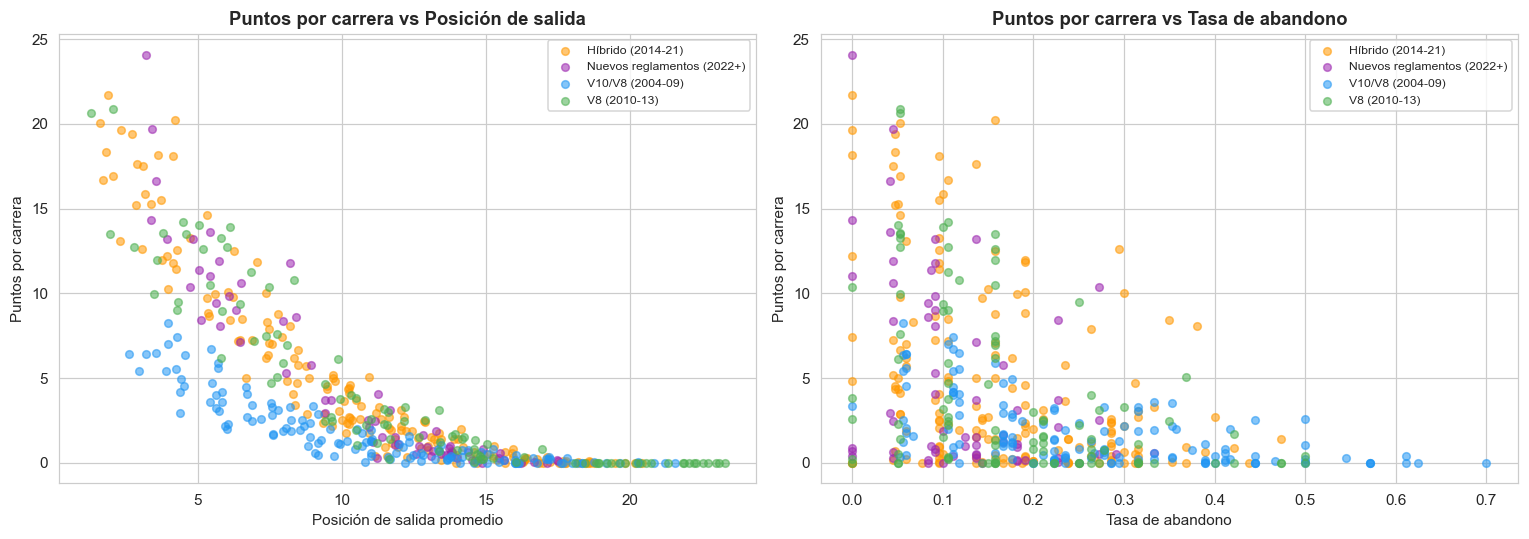

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for era, grp in driver_season.groupby('era'):
    axes[0].scatter(grp['avg_grid'], grp['points_per_race'],
                    c=ERA_COLORS[era], label=era, alpha=0.55, s=25)
axes[0].set_xlabel('Posición de salida promedio')
axes[0].set_ylabel('Puntos por carrera')
axes[0].set_title('Puntos por carrera vs Posición de salida', fontweight='bold')
axes[0].legend(fontsize=8)

for era, grp in driver_season.groupby('era'):
    axes[1].scatter(grp['dnf_rate'], grp['points_per_race'],
                    c=ERA_COLORS[era], label=era, alpha=0.55, s=25)
axes[1].set_xlabel('Tasa de abandono')
axes[1].set_ylabel('Puntos por carrera')
axes[1].set_title('Puntos por carrera vs Tasa de abandono', fontweight='bold')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('../../reports/figures/bivariado_scatter.png', bbox_inches='tight', dpi=150)
plt.show()

### 3.5 Matriz de correlaciones

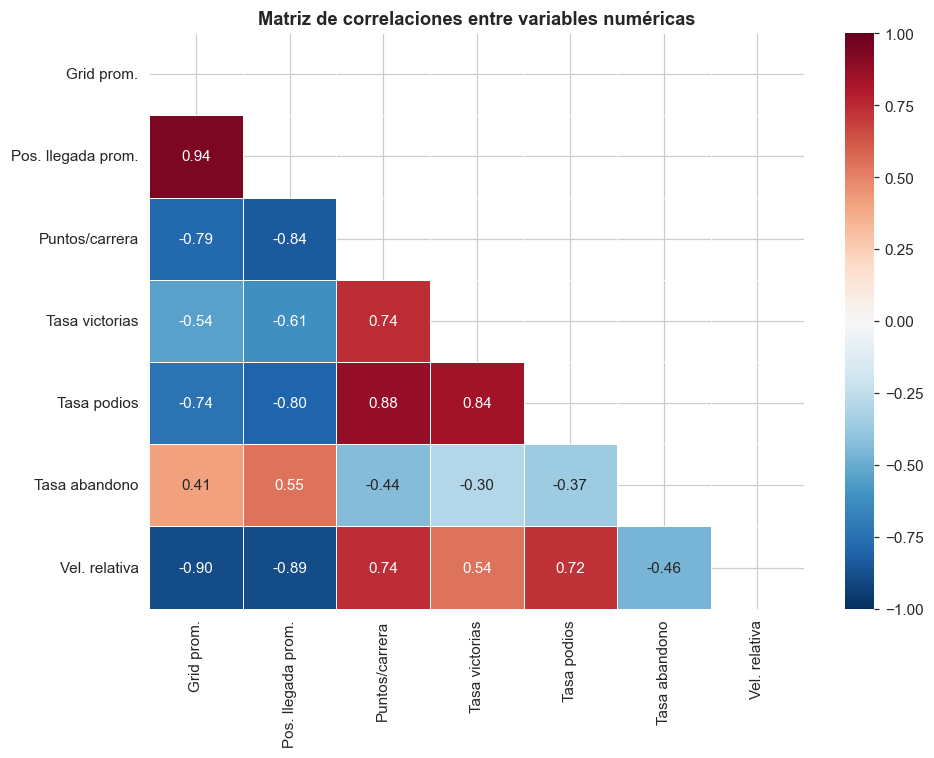

In [54]:
corr_matrix  = driver_season[NUMERIC_VARS].corr()
corr_display = corr_matrix.rename(index=LABELS_SHORT, columns=LABELS_SHORT)

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_display, annot=True, fmt='.2f', cmap='RdBu_r',
    vmin=-1, vmax=1, mask=mask, ax=ax,
    annot_kws={'size': 10}, linewidths=0.5
)
ax.set_title('Matriz de correlaciones entre variables numéricas',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('../../reports/figures/correlacion.png', bbox_inches='tight', dpi=150)
plt.show()

## 4. Análisis de Componentes Principales (PCA)

### 4.1 Preparación: datos completos y estandarización

Se eliminan las filas con valores faltantes en alguna de las variables del PCA.  
El dato de velocidad en vuelta rápida está disponible desde 2004, por lo que las temporadas 2000–2003 quedan excluidas del análisis de componentes principales.

In [55]:
pca_df = driver_season[
    NUMERIC_VARS + ['driver_name', 'year', 'nationality', 'constructor', 'era', 'n_races']
].dropna().copy()

print(f"Observaciones para PCA: {len(pca_df)}")
print(f"Período: {pca_df['year'].min()}–{pca_df['year'].max()}")

X = pca_df[NUMERIC_VARS].values

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"\nMatrix X escalada: {X_scaled.shape}")

Observaciones para PCA: 464
Período: 2004–2024

Matrix X escalada: (464, 7)


### 4.2 Ajuste del PCA y convención de signos

In [56]:
pca    = PCA()
scores = pca.fit_transform(X_scaled)

var_exp = pca.explained_variance_ratio_
var_cum = np.cumsum(var_exp)
n_comp  = len(var_exp)

# El signo de los eigenvectores es arbitrario en PCA.
# Convención adoptada:
#   CP1: 'points_per_race' con carga positiva  → CP1 alto = mejor rendimiento global
#   CP2: 'dnf_rate' con carga positiva         → CP2 alto = mayor tasa de abandono
flip = np.ones(n_comp)
if pca.components_[0, NUMERIC_VARS.index('points_per_race')] < 0:
    flip[0] = -1
if pca.components_[1, NUMERIC_VARS.index('dnf_rate')] < 0:
    flip[1] = -1

scores_plot   = scores   * flip           # (n_obs, n_comp) — coordenadas ajustadas
loadings      = pca.components_.T         # (n_feat, n_comp) — eigenvectores originales
loadings_plot = loadings * flip           # misma convención de signo

# Tabla de varianza explicada
var_table = pd.DataFrame({
    'Componente':         [f'CP{i+1}' for i in range(n_comp)],
    'Varianza expl.':     var_exp.round(4),
    'Var. expl. (%)':     (var_exp * 100).round(2),
    'Var. acumulada (%)': (var_cum * 100).round(2),
})
print(var_table.to_string(index=False))

Componente  Varianza expl.  Var. expl. (%)  Var. acumulada (%)
       CP1          0.7304           73.04               73.04
       CP2          0.1192           11.92               84.96
       CP3          0.0886            8.86               93.82
       CP4          0.0279            2.79               96.62
       CP5          0.0150            1.50               98.12
       CP6          0.0135            1.35               99.47
       CP7          0.0053            0.53              100.00


### 4.3 Gráfico de sedimentación (Scree plot)

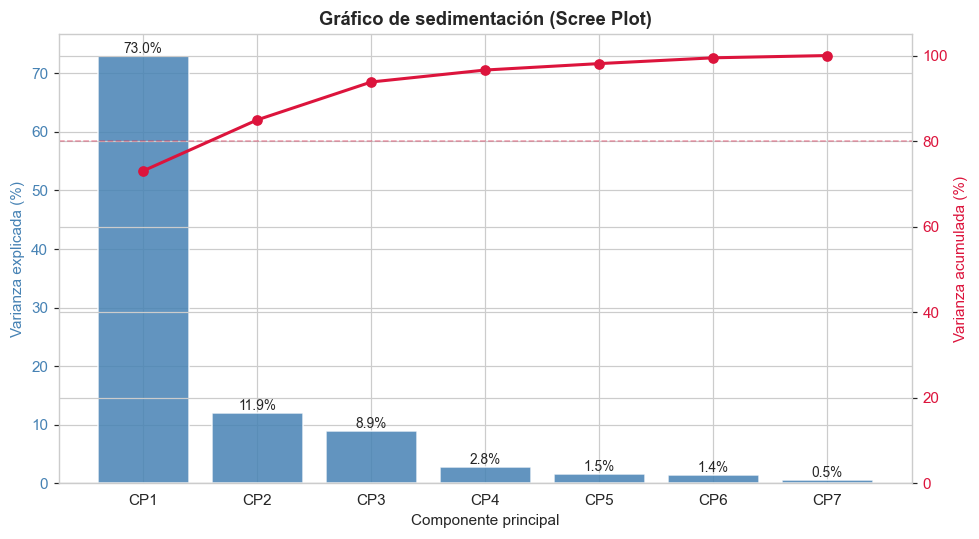

In [57]:
comp_labels = [f'CP{i+1}' for i in range(n_comp)]

fig, ax1 = plt.subplots(figsize=(9, 5))

bars = ax1.bar(comp_labels, var_exp * 100,
               color='steelblue', edgecolor='white', alpha=0.85)
ax1.set_xlabel('Componente principal')
ax1.set_ylabel('Varianza explicada (%)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(comp_labels, var_cum * 100, 'o-', color='crimson', linewidth=2)
ax2.axhline(80, color='crimson', linestyle='--', alpha=0.4, linewidth=1)
ax2.set_ylabel('Varianza acumulada (%)', color='crimson')
ax2.tick_params(axis='y', labelcolor='crimson')
ax2.set_ylim(0, 105)

for b, v in zip(bars, var_exp * 100):
    ax1.text(b.get_x() + b.get_width()/2, v + 0.5, f'{v:.1f}%',
             ha='center', fontsize=9)

ax1.set_title('Gráfico de sedimentación (Scree Plot)', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('../../reports/figures/pca_scree.png', bbox_inches='tight', dpi=150)
plt.show()

### 4.4 Cargas (Loadings) de las componentes principales

In [58]:
feat_labels = [LABELS_SHORT[v] for v in NUMERIC_VARS]

loadings_df = pd.DataFrame(
    loadings_plot,
    index=feat_labels,
    columns=[f'CP{i+1}' for i in range(n_comp)]
)

print("Cargas de las componentes principales (con convención de signo):")
loadings_df.round(3)

Cargas de las componentes principales (con convención de signo):


,CP1,CP2,CP3,CP4,CP5,CP6,CP7
Grid prom.,-0.403,0.106,-0.440,0.001,0.508,-0.097,-0.604
Pos. llegada prom.,-0.423,0.157,-0.213,-0.054,0.326,-0.213,0.773
Puntos/carrera,0.407,0.162,-0.095,0.700,0.118,-0.544,0.013
Tasa victorias,0.341,0.485,-0.481,-0.512,-0.311,-0.243,-0.016
Tasa podios,0.402,0.319,-0.174,0.148,0.404,0.708,0.142
Tasa abandono,-0.244,0.757,0.590,0.023,-0.003,-0.034,-0.132
Vel. relativa,0.395,-0.166,0.377,-0.473,0.601,-0.298,-0.015


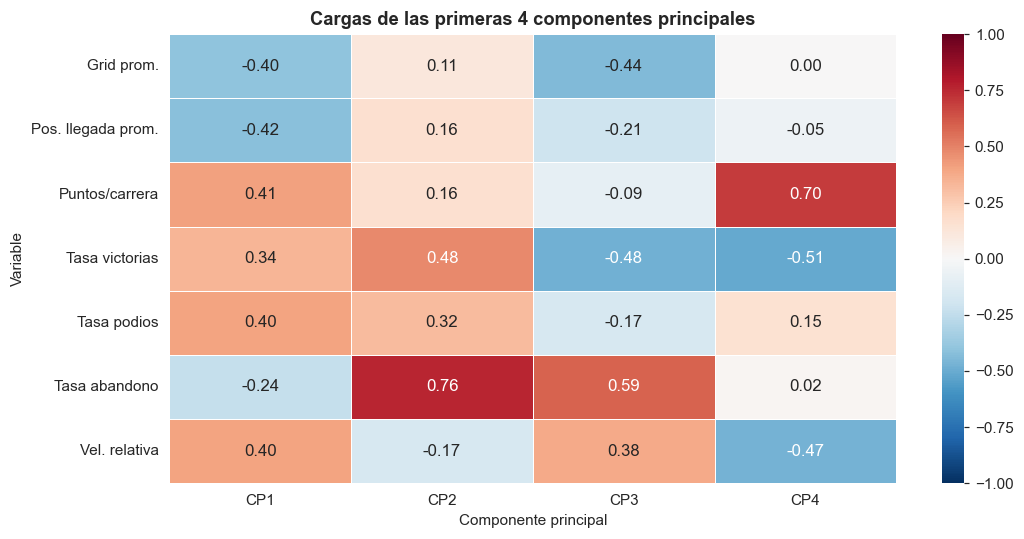

In [59]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    loadings_df.iloc[:, :4].round(2),
    annot=True, fmt='.2f', cmap='RdBu_r',
    vmin=-1, vmax=1, linewidths=0.5, ax=ax,
    annot_kws={'size': 11}
)
ax.set_title('Cargas de las primeras 4 componentes principales',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Componente principal')
ax.set_ylabel('Variable')
plt.tight_layout()
plt.savefig('../../reports/figures/pca_loadings_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()

### 4.5 Círculo de correlaciones (CP1 vs CP2)

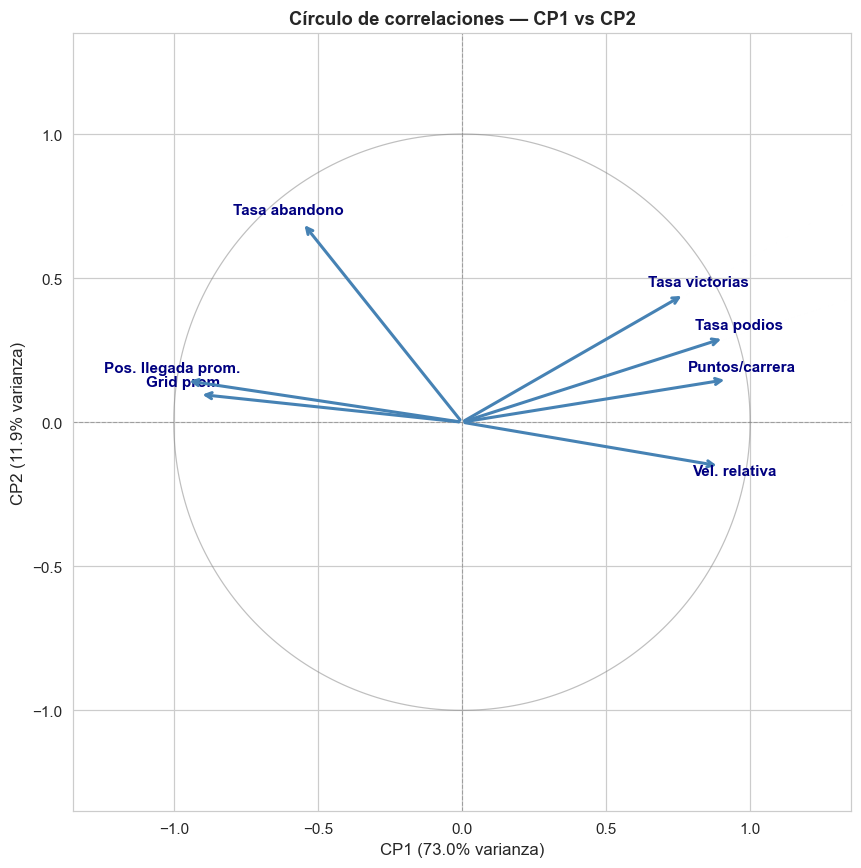

In [60]:
# corr(X_k, CP_j) = loading_plot_{k,j} * sqrt(lambda_j)
eigenvalues    = pca.explained_variance_
corr_vars_pcs  = loadings_plot * np.sqrt(eigenvalues)  # (n_feat, n_comp)

fig, ax = plt.subplots(figsize=(8, 8))

# Círculo unitario
theta = np.linspace(0, 2*np.pi, 300)
ax.plot(np.cos(theta), np.sin(theta), 'gray', linewidth=0.8, alpha=0.5)

for i, var in enumerate(feat_labels):
    cx, cy = corr_vars_pcs[i, 0], corr_vars_pcs[i, 1]
    ax.annotate('', xy=(cx, cy), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='steelblue', lw=2))
    ox = 0.05 if cx >= 0 else -0.05
    oy = 0.03 if cy >= 0 else -0.03
    ax.text(cx + ox, cy + oy, var, fontsize=10, color='navy',
            ha='center', fontweight='bold')

ax.axhline(0, color='gray', linestyle='--', linewidth=0.7, alpha=0.6)
ax.axvline(0, color='gray', linestyle='--', linewidth=0.7, alpha=0.6)
ax.set_xlim(-1.35, 1.35)
ax.set_ylim(-1.35, 1.35)
ax.set_aspect('equal')
ax.set_xlabel(f'CP1 ({var_exp[0]*100:.1f}% varianza)', fontsize=11)
ax.set_ylabel(f'CP2 ({var_exp[1]*100:.1f}% varianza)', fontsize=11)
ax.set_title('Círculo de correlaciones — CP1 vs CP2', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('../../reports/figures/pca_circulo_correlaciones.png', bbox_inches='tight', dpi=150)
plt.show()

### 4.6 Biplot — puntuaciones de los driver-temporadas en CP1 y CP2

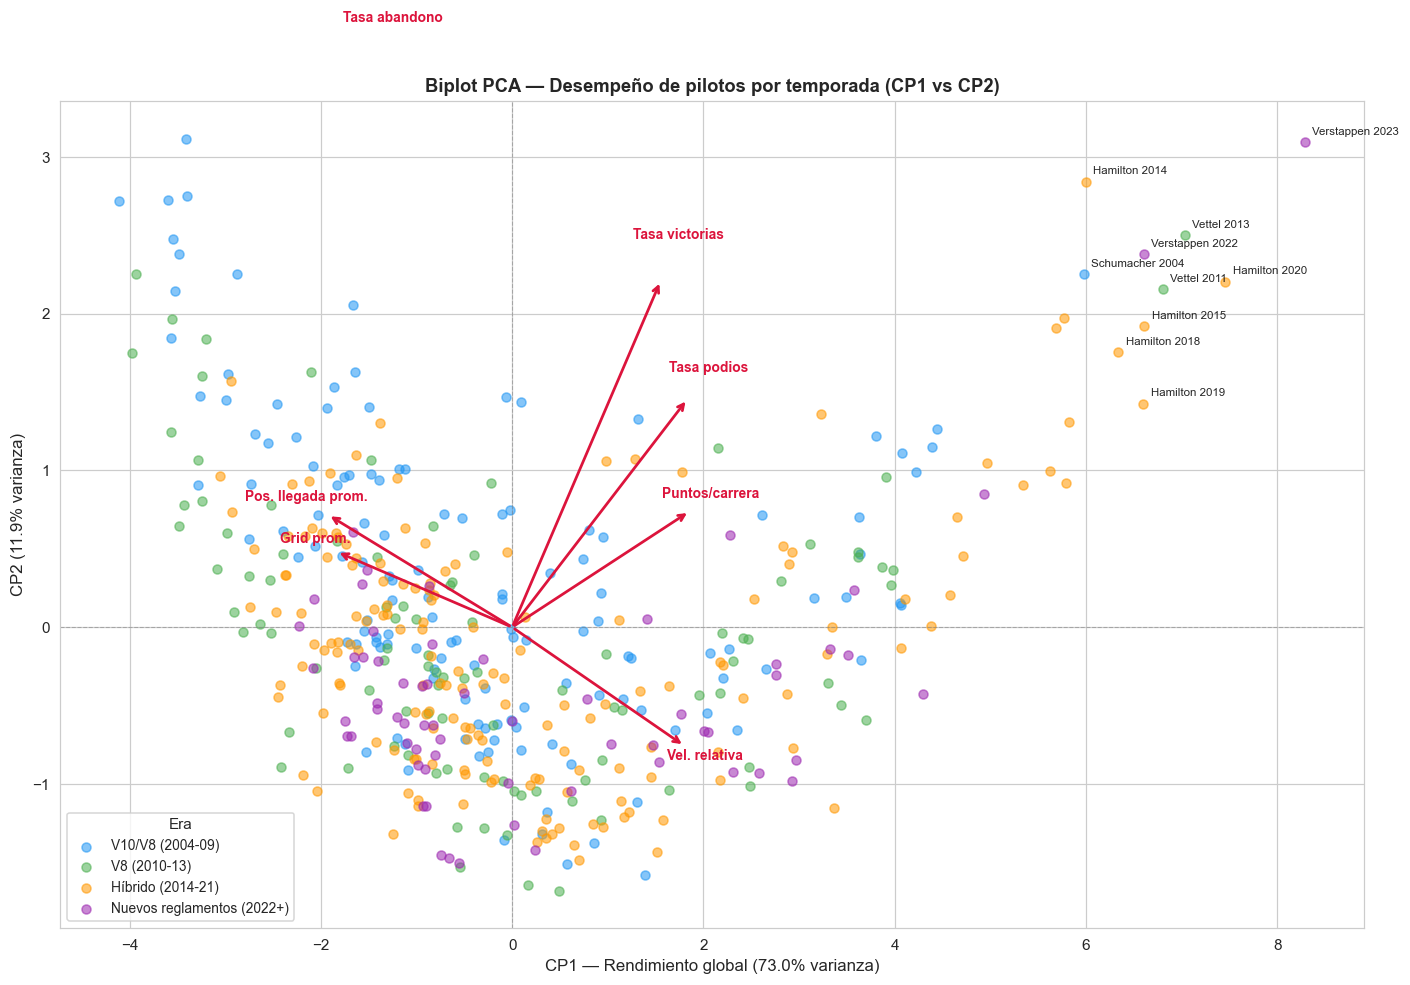

In [61]:
# Guardar puntuaciones ajustadas en el dataframe
for i in range(n_comp):
    pca_df[f'CP{i+1}'] = scores_plot[:, i]

fig, ax = plt.subplots(figsize=(13, 9))

for era in ERA_ORDER:
    grp = pca_df[pca_df['era'] == era]
    ax.scatter(grp['CP1'], grp['CP2'], c=ERA_COLORS[era],
               label=era, alpha=0.55, s=35, zorder=2)

# Flechas de variables (cargas escaladas para visibilidad en el mismo espacio)
scale = max(abs(scores_plot[:, :2].ravel())) * 0.55
for i, var in enumerate(feat_labels):
    lx, ly = loadings_plot[i, 0] * scale, loadings_plot[i, 1] * scale
    ax.annotate('', xy=(lx, ly), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='crimson', lw=1.8))
    ax.text(lx * 1.12, ly * 1.12, var, color='crimson',
            fontsize=9, ha='center', fontweight='bold')

# Anotar los 10 driver-temporadas con mayor CP1 (mejores performers)
for _, row in pca_df.nlargest(10, 'CP1').iterrows():
    label = f"{row['driver_name'].split()[-1]} {row['year']}"
    ax.annotate(label, (row['CP1'], row['CP2']),
                xytext=(5, 5), textcoords='offset points',
                fontsize=7.5, color='black', alpha=0.85)

ax.axhline(0, color='gray', linestyle='--', linewidth=0.7, alpha=0.5)
ax.axvline(0, color='gray', linestyle='--', linewidth=0.7, alpha=0.5)
ax.set_xlabel(f'CP1 — Rendimiento global ({var_exp[0]*100:.1f}% varianza)', fontsize=11)
ax.set_ylabel(f'CP2 ({var_exp[1]*100:.1f}% varianza)', fontsize=11)
ax.set_title('Biplot PCA — Desempeño de pilotos por temporada (CP1 vs CP2)',
             fontweight='bold', fontsize=12)
ax.legend(title='Era', fontsize=9)
plt.tight_layout()
plt.savefig('../../reports/figures/pca_biplot_era.png', bbox_inches='tight', dpi=150)
plt.show()

### 4.7 Extremos de CP1: mejores y peores temporadas

In [62]:
cols_show = ['driver_name', 'year', 'constructor', 'avg_grid',
             'points_per_race', 'win_rate', 'podium_rate', 'dnf_rate',
             'avg_rel_speed', 'CP1', 'CP2']

print("=== TOP 10 — Mayor CP1 (mejor rendimiento global) ===")
print(pca_df.nlargest(10, 'CP1')[cols_show].round(3).to_string(index=False))

print("\n=== BOTTOM 10 — Menor CP1 (menor rendimiento global) ===")
print(pca_df.nsmallest(10, 'CP1')[cols_show].round(3).to_string(index=False))

=== TOP 10 — Mayor CP1 (mejor rendimiento global) ===
       driver_name  year constructor  avg_grid  points_per_race  win_rate  podium_rate  dnf_rate  avg_rel_speed   CP1   CP2
    Max Verstappen  2023    Red Bull     3.182           24.091     0.864        0.955     0.000          1.461 8.284 3.093
    Lewis Hamilton  2020    Mercedes     1.875           21.688     0.688        0.875     0.000          1.395 7.454 2.204
  Sebastian Vettel  2013    Red Bull     2.053           20.895     0.684        0.842     0.053          1.218 7.032 2.501
  Sebastian Vettel  2011    Red Bull     1.263           20.632     0.579        0.895     0.053          1.111 6.799 2.155
    Lewis Hamilton  2015    Mercedes     1.579           20.053     0.526        0.895     0.053          1.134 6.606 1.920
    Max Verstappen  2022    Red Bull     3.409           19.682     0.682        0.773     0.045          1.191 6.604 2.379
    Lewis Hamilton  2019    Mercedes     2.333           19.667     0.524     

### 4.8 Análisis de CP2

In [63]:
print("=== TOP 10 — Mayor CP2 (mayor tasa de abandono relativa) ===")
print(pca_df.nlargest(10, 'CP2')[cols_show].round(3).to_string(index=False))

print("\n=== BOTTOM 10 — Menor CP2 (mayor confiabilidad / consistencia) ===")
print(pca_df.nsmallest(10, 'CP2')[cols_show].round(3).to_string(index=False))

=== TOP 10 — Mayor CP2 (mayor tasa de abandono relativa) ===
       driver_name  year constructor  avg_grid  points_per_race  win_rate  podium_rate  dnf_rate  avg_rel_speed    CP1   CP2
       Scott Speed  2007  Toro Rosso    17.700            0.000     0.000        0.000     0.700         -1.155 -3.414 3.117
    Max Verstappen  2023    Red Bull     3.182           24.091     0.864        0.955     0.000          1.461  8.284 3.093
    Lewis Hamilton  2014    Mercedes     4.211           20.211     0.579        0.842     0.158          0.929  5.996 2.842
 Jaime Alguersuari  2009  Toro Rosso    16.125            0.000     0.000        0.000     0.625         -1.682 -3.398 2.752
      Adrian Sutil  2008 Force India    19.167            0.000     0.000        0.000     0.611         -1.522 -3.599 2.724
   Franck Montagny  2006 Super Aguri    20.286            0.000     0.000        0.000     0.571         -2.228 -4.105 2.717
  Sebastian Vettel  2013    Red Bull     2.053           20.895 

### 4.9 Evolución temporal de CP1: trayectorias de los mejores pilotos

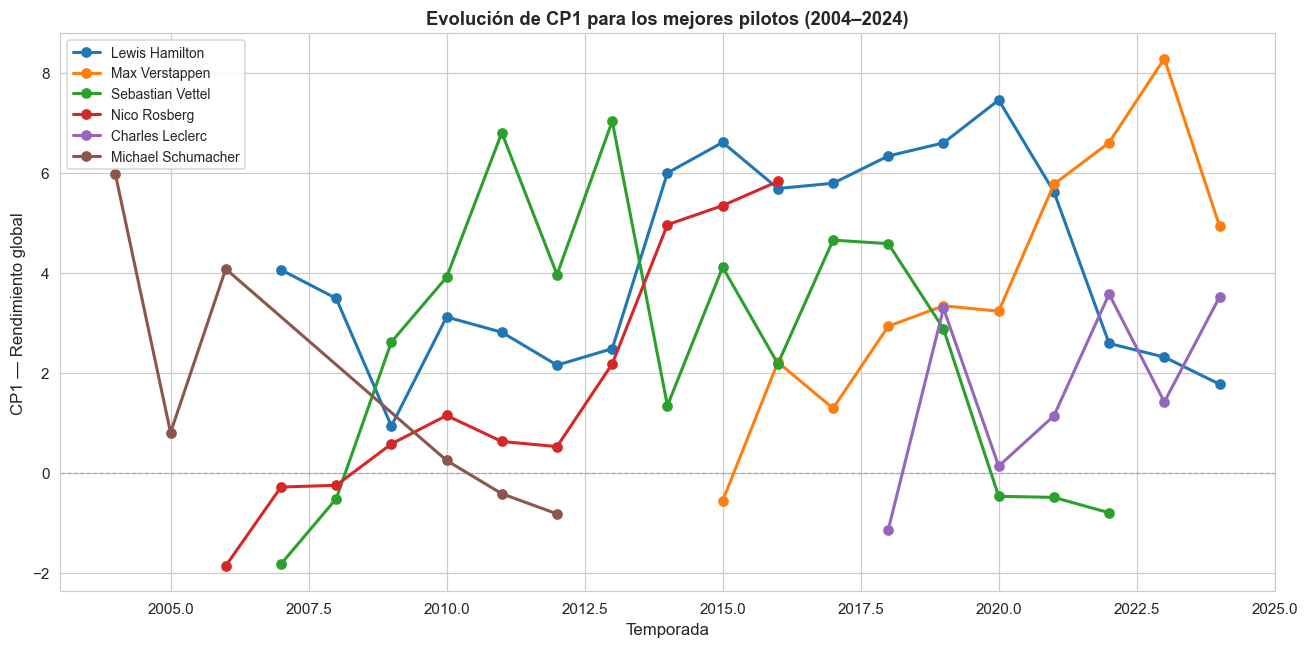

In [64]:
top_drivers = pca_df.groupby('driver_name')['CP1'].mean().nlargest(6).index.tolist()

fig, ax = plt.subplots(figsize=(12, 6))
palette = plt.cm.tab10.colors

for i, driver in enumerate(top_drivers):
    grp = pca_df[pca_df['driver_name'] == driver].sort_values('year')
    ax.plot(grp['year'], grp['CP1'], 'o-', label=driver,
            color=palette[i], linewidth=2, markersize=6)

ax.axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_xlabel('Temporada', fontsize=11)
ax.set_ylabel('CP1 — Rendimiento global', fontsize=11)
ax.set_title('Evolución de CP1 para los mejores pilotos (2004–2024)',
             fontweight='bold', fontsize=12)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('../../reports/figures/pca_evolucion_cp1.png', bbox_inches='tight', dpi=150)
plt.show()

### 4.10 Biplot CP1 vs CP3

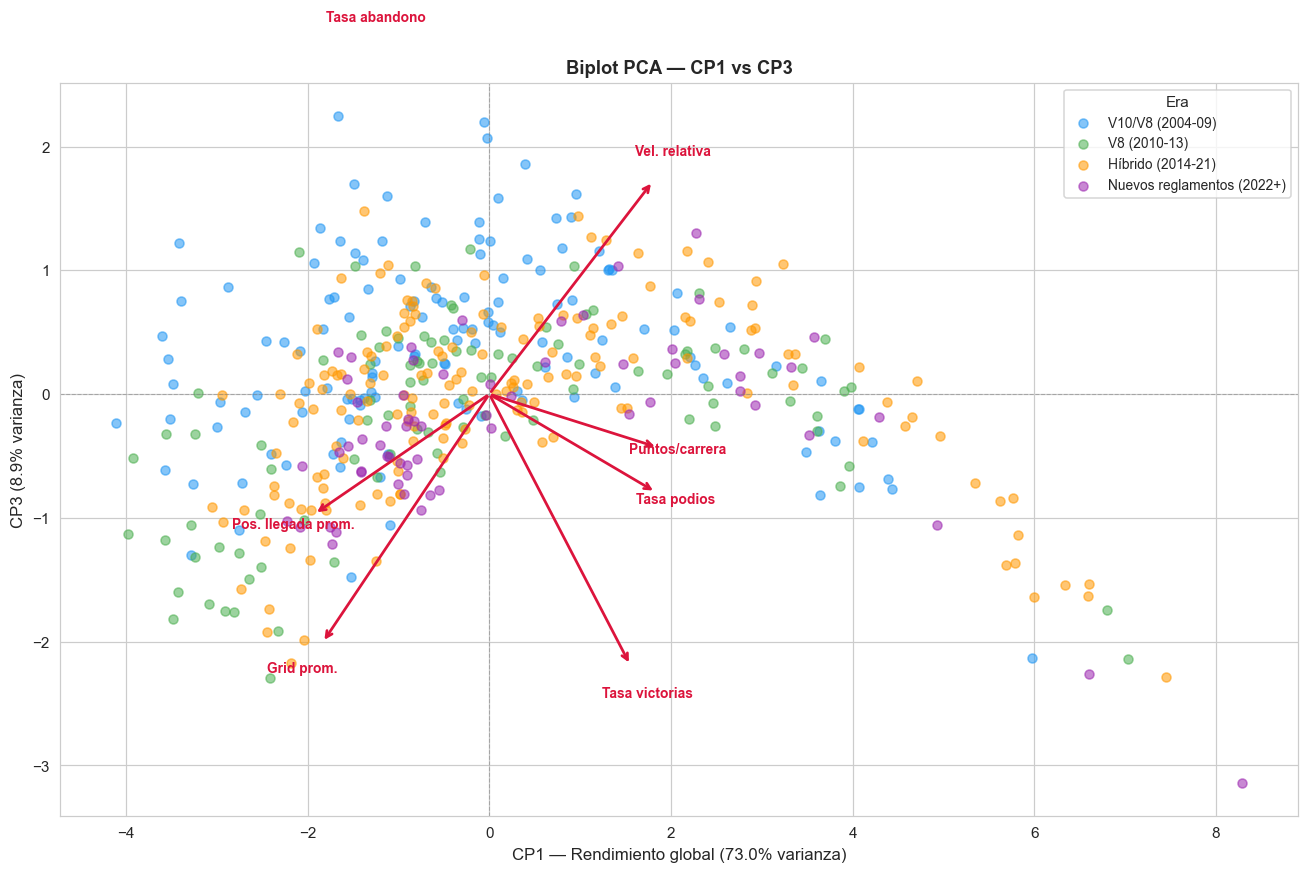

In [65]:
fig, ax = plt.subplots(figsize=(12, 8))

for era in ERA_ORDER:
    grp = pca_df[pca_df['era'] == era]
    ax.scatter(grp['CP1'], grp['CP3'], c=ERA_COLORS[era],
               label=era, alpha=0.55, s=35, zorder=2)

scale3 = max(abs(np.c_[scores_plot[:, 0], scores_plot[:, 2]].ravel())) * 0.55
for i, var in enumerate(feat_labels):
    lx = loadings_plot[i, 0] * scale3
    lz = loadings_plot[i, 2] * scale3
    ax.annotate('', xy=(lx, lz), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='crimson', lw=1.8))
    ax.text(lx * 1.12, lz * 1.12, var, color='crimson',
            fontsize=9, ha='center', fontweight='bold')

ax.axhline(0, color='gray', linestyle='--', linewidth=0.7, alpha=0.5)
ax.axvline(0, color='gray', linestyle='--', linewidth=0.7, alpha=0.5)
ax.set_xlabel(f'CP1 — Rendimiento global ({var_exp[0]*100:.1f}% varianza)', fontsize=11)
ax.set_ylabel(f'CP3 ({var_exp[2]*100:.1f}% varianza)', fontsize=11)
ax.set_title('Biplot PCA — CP1 vs CP3', fontweight='bold', fontsize=12)
ax.legend(title='Era', fontsize=9)
plt.tight_layout()
plt.savefig('../../reports/figures/pca_biplot_cp1_cp3.png', bbox_inches='tight', dpi=150)
plt.show()

## 5. Interpretación de las componentes principales

*(Completar con los valores exactos que surjan de las celdas anteriores al redactar el informe.)*

---

### CP1 — Rendimiento global

La primera componente explica **~73%** de la varianza total. Las variables con mayor carga positiva son **puntos por carrera, tasa de victorias, tasa de podios y velocidad relativa**; y con carga negativa la **posición de salida y de llegada** (donde un número menor significa mejor resultado, de ahí el signo invertido).

**Interpretación:** CP1 es el *eje de rendimiento global*. Un valor alto corresponde a temporadas dominantes (muchos puntos, victorias, alta velocidad en vuelta rápida). Los driver-temporadas en el extremo superior corresponden a los grandes campeones en sus mejores años (Verstappen 2023, Hamilton en el ciclo Mercedes, Vettel con Red Bull). En el extremo inferior se ubican pilotos de equipos traseros con bajos resultados.

---

### CP2 — Confiabilidad / Tasa de abandono

La segunda componente explica **~12%**. Está dominada por la **tasa de abandono** (carga positiva fuerte). Las cargas en las demás variables son considerablemente menores.

**Interpretación:** CP2 captura la *fiabilidad mecánica y de carrera*. Pilotos con CP2 alto tuvieron muchos abandonos en esa temporada (ya sea por fallas mecánicas, accidentes o autos no competitivos). Pilotos con CP2 bajo terminaron sus carreras de manera consistente, independientemente de su nivel de desempeño global (CP1).

---

### CP3 — Clasificación vs Carrera

La tercera componente explica **~9%** y contrasta principalmente la **posición de salida** (clasificación) con la **velocidad en vuelta rápida**. Captura pilotos que rinden especialmente bien en clasificación pero tienen menor ritmo de carrera, y viceversa.


In [66]:
n_80 = int(np.searchsorted(var_cum, 0.80)) + 1
n_90 = int(np.searchsorted(var_cum, 0.90)) + 1
print(f"Componentes necesarias para explicar el 80% de la varianza: {n_80}")
print(f"Componentes necesarias para explicar el 90% de la varianza: {n_90}")
print(f"\nVarianza explicada por CP1+CP2:      {var_cum[1]*100:.1f}%")
print(f"Varianza explicada por CP1+CP2+CP3:  {var_cum[2]*100:.1f}%")

Componentes necesarias para explicar el 80% de la varianza: 2
Componentes necesarias para explicar el 90% de la varianza: 3

Varianza explicada por CP1+CP2:      85.0%
Varianza explicada por CP1+CP2+CP3:  93.8%
